
# Replicating the computer simulations of *A Statistical Model of Criminal Behavior*

This notebook implements the **discrete agent-based lattice model** from Short et al., *A Statistical Model of Criminal Behavior* (2008), focusing on the parameter set of **Fig. 3(d)**.

The goal is not to reproduce pixel-perfect images from the paper, because the model is stochastic and the original random seed is not published. The goal is to reproduce the qualitative regime: **low criminal numbers with dynamic hotspots that persist, deform, and move over time**.

## Parameter set d

The paper states that all four Fig. 3 simulations use:

\[
$\ell = 1, \qquad \delta t = \frac{1}{100}, \qquad \omega = \frac{1}{15}, \qquad A^0 = \frac{1}{30}$,
\]

on a \(128 \times 128\) grid. For panel **d** specifically:

\[
$\eta = 0.03, \qquad \theta = 5.6, \qquad \Gamma = 0.002.$
\]

The snapshots shown in the paper for panel d are at:

\[
$t = 15, \quad 50, \quad 730 \text{ days}$.
\]



# 1. Model explanation

The urban environment is represented as a square lattice. Each site \(s\) is a possible target, for example a house. Each site has a **total attractiveness**

\[
$A_s(t) = A_s^0 + B_s(t)$,
\]

where:

- $\(A_s^0\) $is the fixed baseline attractiveness of the site;
- $\(B_s(t)\)$ is the dynamic attractiveness caused by previous burglaries.

Criminals are mobile agents. At each timestep, a criminal located at site \(s\):

1. commits a burglary with probability

\[
$p_s(t) = 1 - \exp[-A_s(t)\delta t]$,
\]

2. if no burglary occurs, moves to one of the four neighboring sites with probability biased toward attractiveness:

\[
$q_{s \to s'}(t) = \frac{A_{s'}(t)}{\sum_{r \sim s} A_r(t)}$.
\]

The dynamic attractiveness evolves according to:

\[
$B_s(t+\delta t) =
\left[(1-\eta)B_s(t) + \frac{\eta}{z}\sum_{s'\sim s} B_{s'}(t)\right]
(1-\omega\delta t) + \theta E_s(t)$,
\]

where:

- $\(E_s(t)\)$ is the number of burglaries at site \(s\) during the timestep;
- \(z=4\) is the number of nearest neighbors on a square lattice;
- $\(\eta\)$ controls spatial spreading of attractiveness;
- $\(\omega\)$ controls decay of attractiveness;
- $\(\theta\)$ is the attractiveness boost produced by one burglary.

New criminals are generated at each site with rate \(\Gamma\). Computationally, this is implemented as a Poisson process.



# 2. Algorithm

For each timestep:

1. Compute total attractiveness \(A=A^0+B\).
2. For every criminal, sample whether they commit a burglary using \(p=1-e^{-A\delta t}\).
3. Remove criminals who burgle from the active criminal list.
4. Record the burglary count field \(E_s(t)\).
5. Move non-burgling criminals to neighboring sites with probability proportional to neighboring attractiveness.
6. Generate new criminals as a Poisson process with mean \(\Gamma\delta t\) per site.
7. Update \(B\) using diffusion-like spreading, decay, and burglary reinforcement.
8. Store snapshots at \(t=15,50,730\) days.

Periodic boundary conditions are used. This is the standard choice for avoiding artificial boundary effects in lattice pattern-formation simulations.


In [1]:

# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# For reproducibility of this notebook run.
SEED = 42
rng = np.random.default_rng(SEED)

OUT_DIR = Path("crime_model_outputs")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)


In [2]:

# ============================================================
# Parameters: Fig. 3(d)
# ============================================================

# Lattice
L = 128                  # 128 x 128 grid
ell = 1.0                # grid spacing
z = 4                    # square lattice coordination number

# Time
dt = 1 / 100             # days
T_max = 730              # days
snapshot_days = [15, 50, 730]

# Model parameters common to all Fig. 3 cases
omega = 1 / 15           # dynamic attractiveness decay rate
A0 = 1 / 30              # baseline attractiveness, uniform

# Fig. 3(d) parameters
eta = 0.03               # neighborhood spreading of attractiveness
theta = 5.6              # boost in attractiveness per burglary
Gamma = 0.002            # criminal generation rate per site

# Homogeneous equilibrium values from the paper
B_bar = theta * Gamma / omega
A_bar = A0 + B_bar
n_bar = Gamma * dt / (1 - np.exp(-A_bar * dt))
expected_initial_criminals = n_bar * L * L

print(f"B_bar = {B_bar:.4f}")
print(f"A_bar = {A_bar:.4f}")
print(f"n_bar per site = {n_bar:.5f}")
print(f"Expected initial criminals = {expected_initial_criminals:.1f}")
print(f"Total timesteps = {int(T_max / dt):,}")


B_bar = 0.1680
A_bar = 0.2013
n_bar per site = 0.00994
Expected initial criminals = 162.9
Total timesteps = 73,000


In [3]:

# ============================================================
# Core utilities
# ============================================================

def initialize_state(L, B_bar, n_bar, rng):
    """Initialize B at homogeneous equilibrium and criminal positions randomly."""
    B = np.full((L, L), B_bar, dtype=np.float64)
    n0 = rng.poisson(n_bar * L * L)
    x = rng.integers(0, L, size=n0, dtype=np.int32)
    y = rng.integers(0, L, size=n0, dtype=np.int32)
    return B, x, y


def update_B(B, E, eta, omega, theta, dt):
    """Update dynamic attractiveness B with periodic boundaries."""
    neigh_avg = (
        np.roll(B, 1, axis=0) +
        np.roll(B, -1, axis=0) +
        np.roll(B, 1, axis=1) +
        np.roll(B, -1, axis=1)
    ) / 4.0
    B_next = ((1 - eta) * B + eta * neigh_avg) * (1 - omega * dt) + theta * E
    return B_next


def move_surviving_criminals(x, y, A, rng):
    """
    Move criminals to one of the four nearest-neighbor sites.
    The move probability is proportional to the attractiveness of the destination.
    Periodic boundaries are used.
    """
    if len(x) == 0:
        return x, y

    L = A.shape[0]

    # Candidate destinations: up, down, left, right.
    x_up = (x - 1) % L
    y_up = y

    x_down = (x + 1) % L
    y_down = y

    x_left = x
    y_left = (y - 1) % L

    x_right = x
    y_right = (y + 1) % L

    weights = np.vstack([
        A[x_up, y_up],
        A[x_down, y_down],
        A[x_left, y_left],
        A[x_right, y_right],
    ]).T

    probs = weights / weights.sum(axis=1, keepdims=True)
    cumulative = np.cumsum(probs, axis=1)
    u = rng.random(len(x))
    choices = (u[:, None] > cumulative).sum(axis=1)

    x_new = x.copy()
    y_new = y.copy()

    mask = choices == 0
    x_new[mask], y_new[mask] = x_up[mask], y_up[mask]

    mask = choices == 1
    x_new[mask], y_new[mask] = x_down[mask], y_down[mask]

    mask = choices == 2
    x_new[mask], y_new[mask] = x_left[mask], y_left[mask]

    mask = choices == 3
    x_new[mask], y_new[mask] = x_right[mask], y_right[mask]

    return x_new, y_new


def generate_new_criminals(L, Gamma, dt, rng):
    """
    Generate new criminals.
    Independent Poisson(Gamma*dt) arrivals at each site are equivalent to drawing
    a total Poisson(Gamma*dt*L*L) number and placing them uniformly at random.
    """
    n_new = rng.poisson(Gamma * dt * L * L)
    x_new = rng.integers(0, L, size=n_new, dtype=np.int32)
    y_new = rng.integers(0, L, size=n_new, dtype=np.int32)
    return x_new, y_new


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path

# ============================================================
# HELPER: comptar criminals per cel·la
# ============================================================
def criminals_to_grid(criminal_positions, L):
    """
    criminal_positions: array/list de posicions [(i,j), ...]
    L: mida de la graella (L x L)
    """
    grid = np.zeros((L, L), dtype=int)
    for i, j in criminal_positions:
        grid[i % L, j % L] += 1
    return grid


# ============================================================
# HELPER: guardar un frame
# ============================================================
def save_frame(array2d, step, outdir, title="Dynamic attractiveness", cmap="hot"):
    """
    Guarda una imatge PNG d'un estat de la simulació.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(array2d, origin="lower", cmap=cmap)
    ax.set_title(f"{title} | step = {step}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fname = outdir / f"frame_{step:06d}.png"
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.close(fig)

    return fname


# ============================================================
# HELPER: construir el GIF
# ============================================================
def make_gif_from_frames(frame_paths, gif_name="simulation.gif", fps=8):
    """
    Construeix un GIF a partir d'una llista de PNGs.
    """
    images = [imageio.imread(fp) for fp in frame_paths]
    imageio.mimsave(gif_name, images, fps=fps)
    print(f"GIF guardat a: {gif_name}")

In [5]:
def run_discrete_crime_simulation(
    L=128,
    dt=1/100,
    T_max=730,
    snapshot_days=(15, 50, 730),
    A0=1/30,
    omega=1/15,
    eta=0.03,
    theta=5.6,
    Gamma=0.002,
    seed=42,
    progress_every_days=50,
    make_gif=False,
    gif_every_days=2,
    gif_name="crime_hotspots_fig3d.gif",
    gif_fps=10,
):
    rng = np.random.default_rng(seed)

    B_bar = theta * Gamma / omega
    A_bar = A0 + B_bar
    n_bar = Gamma * dt / (1 - np.exp(-A_bar * dt))

    B, x, y = initialize_state(L, B_bar, n_bar, rng)

    n_steps = int(round(T_max / dt))
    snapshot_steps = {int(round(day / dt)): day for day in snapshot_days}
    progress_every_steps = max(1, int(round(progress_every_days / dt)))

    snapshots = {}
    rows = []

    # ========================================================
    # GIF setup
    # ========================================================
    gif_frames = []
    gif_every_steps = max(1, int(round(gif_every_days / dt)))

    # fixed colormap and fixed scale
    gif_cmap = "turbo"
    vmin_gif = 0.0
    vmax_gif = 0.33

    for step in range(1, n_steps + 1):
        t = step * dt
        A = A0 + B

        # 1) Burglaries
        E = np.zeros((L, L), dtype=np.int16)
        if len(x) > 0:
            p_crime = 1 - np.exp(-A[x, y] * dt)
            commits_crime = rng.random(len(x)) < p_crime

            if commits_crime.any():
                np.add.at(E, (x[commits_crime], y[commits_crime]), 1)

            x = x[~commits_crime]
            y = y[~commits_crime]

        # 2) Move survivors
        x, y = move_surviving_criminals(x, y, A, rng)

        # 3) Generate new criminals
        x_new, y_new = generate_new_criminals(L, Gamma, dt, rng)
        if len(x_new) > 0:
            x = np.concatenate([x, x_new])
            y = np.concatenate([y, y_new])

        # 4) Update B
        B = update_B(B, E, eta, omega, theta, dt)
        A_total = A0 + B
        # ========================================================
        # GIF frame
        # ========================================================
        if make_gif and step % gif_every_steps == 0:
            fig, ax = plt.subplots(figsize=(6, 6), facecolor="0.92")

            im = ax.imshow(
                A_total,
                origin="lower",
                cmap=gif_cmap,
                vmin=vmin_gif,
                vmax=vmax_gif
            )

            ax.set_title(f"Dynamic attractiveness $A$ | day {t:.1f}")
            ax.set_xlabel("x")
            ax.set_ylabel("y")

            cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(r"dynamic attractiveness $A_s$")

            plt.tight_layout()
            fig.canvas.draw()

            frame = np.asarray(fig.canvas.buffer_rgba())
            gif_frames.append(frame.copy())

            plt.close(fig)

        # 5) Store snapshots
        if step in snapshot_steps:
            snapshots[snapshot_steps[step]] = {
                "A": A_total.copy(),
                "n_criminals": len(x),
                "t": t,
            }

        # diagnostics every day
        if step % int(round(1 / dt)) == 0:
            rows.append({
                "day": t,
                "n_criminals": len(x),
                "n_crimes_that_day_proxy": int(E.sum()),
                "A_mean": float(A_total.mean()),
                "A_std": float(A_total.std()),
                "hotspot_index_std_over_mean": float(A_total.std() / A_total.mean()),
                "fraction_A_above_2Abar": float((A_total >= 2 * A_bar).mean()),
            })

        if progress_every_days is not None and step % progress_every_steps == 0:
            print(f"t = {t:7.1f} days | criminals = {len(x):5d} | A_std/A_mean = {A_total.std()/A_total.mean():.3f}")

    diagnostics = pd.DataFrame(rows)

    if make_gif and len(gif_frames) > 0:
        imageio.mimsave(gif_name, gif_frames, fps=gif_fps)
        print(f"GIF saved as: {gif_name}")
    else: print("No GIF frames were generated.")

    return snapshots, diagnostics


# 3. Run the simulation

The full replication uses a 128×128 grid and 73,000 timesteps. Depending on your laptop, it may take a few minutes.

For a very fast smoke test, set `RUN_FULL = False`. For the actual Fig. 3(d) replication, leave it as `True`.


In [6]:

RUN_FULL = True

if RUN_FULL:
    sim_L = 128
    sim_T_max = 730
    sim_snapshot_days = [15, 50, 730]
else:
    # Fast test: not a real replication, just checks that the code runs.
    sim_L = 64
    sim_T_max = 30
    sim_snapshot_days = [5, 15, 30]

snapshots, diagnostics = run_discrete_crime_simulation(
    L=sim_L,
    dt=dt,
    T_max=sim_T_max,
    snapshot_days=sim_snapshot_days,
    A0=A0,
    omega=omega,
    eta=eta,
    theta=theta,
    Gamma=Gamma,
    seed=SEED,
    progress_every_days=50 if RUN_FULL else 5,
    make_gif=RUN_FULL,
)

diagnostics.tail()


t =    50.0 days | criminals =    89 | A_std/A_mean = 1.250
t =   100.0 days | criminals =    64 | A_std/A_mean = 1.451
t =   150.0 days | criminals =    72 | A_std/A_mean = 1.341
t =   200.0 days | criminals =    59 | A_std/A_mean = 1.317
t =   250.0 days | criminals =    79 | A_std/A_mean = 1.243
t =   300.0 days | criminals =    76 | A_std/A_mean = 1.372
t =   350.0 days | criminals =    77 | A_std/A_mean = 1.183
t =   400.0 days | criminals =    72 | A_std/A_mean = 1.433
t =   450.0 days | criminals =    67 | A_std/A_mean = 1.314
t =   500.0 days | criminals =    75 | A_std/A_mean = 1.289
t =   550.0 days | criminals =    66 | A_std/A_mean = 1.242
t =   600.0 days | criminals =    69 | A_std/A_mean = 1.321
t =   650.0 days | criminals =    60 | A_std/A_mean = 1.243
t =   700.0 days | criminals =    57 | A_std/A_mean = 1.350
GIF saved as: crime_hotspots_fig3d.gif


,day,n_criminals,n_crimes_that_day_proxy,A_mean,A_std,hotspot_index_std_over_mean,fraction_A_above_2Abar
725,726.0,67,0,0.202565,0.253576,1.251826,0.108582
726,727.0,76,1,0.204866,0.261928,1.278534,0.111450
727,728.0,62,1,0.207704,0.289672,1.394643,0.114502
728,729.0,61,0,0.206408,0.268793,1.302244,0.115112
729,730.0,49,0,0.207859,0.280372,1.348859,0.115295


In [7]:

# Save diagnostics

diagnostics.to_csv(OUT_DIR / "fig3d_diagnostics.csv", index=False)
print(f"Saved diagnostics to {OUT_DIR / 'fig3d_diagnostics.csv'}")


Saved diagnostics to crime_model_outputs/fig3d_diagnostics.csv



# 4. Plot snapshots: replication of Fig. 3(d)

The paper uses a color scale where:

- violet/blue roughly corresponds to \(B_s \approx 0\),
- green is the homogeneous equilibrium \(\bar B\),
- red corresponds to \(B_s \geq 2\bar B\).

Here I reproduce that convention using `vmin=0` and `vmax=2*B_bar`.


KeyError: 'B'

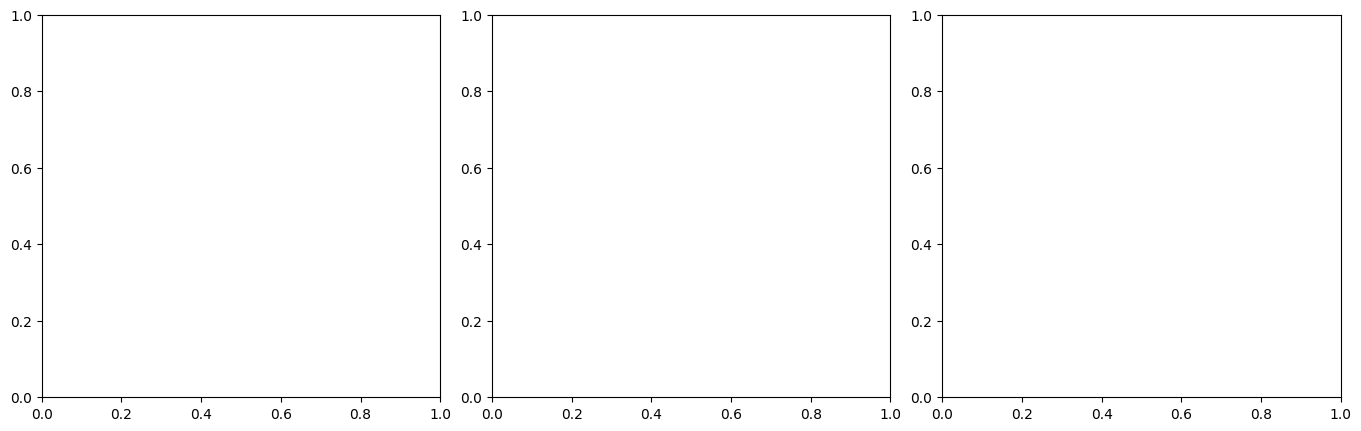

In [8]:

def plot_snapshots(snapshots, B_bar, title="Short et al. crime model: Fig. 3(d) replication"):
    days = list(snapshots.keys())
    n = len(days)

    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2), constrained_layout=True)
    if n == 1:
        axes = [axes]

    last_im = None
    for ax, day in zip(axes, days):
        B = snapshots[day]["B"]
        n_criminals = snapshots[day]["n_criminals"]
        last_im = ax.imshow(
            B,
            origin="lower",
            cmap="rainbow",
            vmin=0,
            vmax=2 * B_bar,
            interpolation="nearest",
        )
        ax.set_title(f"t = {day} days\n{n_criminals} criminals")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.colorbar(last_im, ax=axes, shrink=0.8, label="dynamic attractiveness $B_s$")
    fig.suptitle(title, y=1.05)
    return fig

fig = plot_snapshots(snapshots, B_bar)
fig.savefig(FIG_DIR / "fig3d_replication_snapshots.png", dpi=200, bbox_inches="tight")
plt.show()



# 5. Diagnostics

The important qualitative signature of panel d is not a fixed final lattice, but a **regime**:

- the number of criminals remains low compared with panels a/c;
- the attractiveness field becomes spatially heterogeneous;
- hotspots are present but stochastic, moving and deforming rather than settling into a perfectly stationary crystal-like pattern.

The next plots help diagnose that behavior.


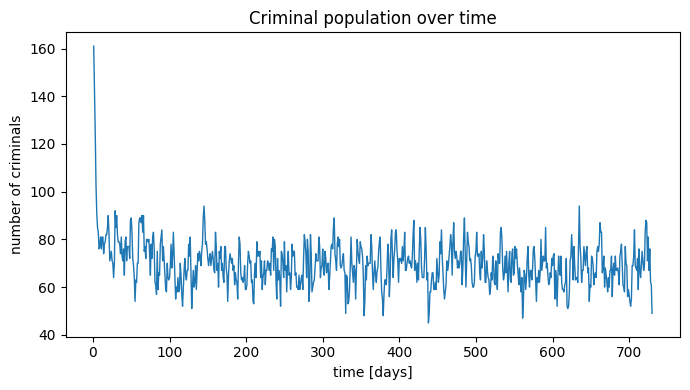

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(diagnostics["day"], diagnostics["n_criminals"], lw=1)
plt.xlabel("time [days]")
plt.ylabel("number of criminals")
plt.title("Criminal population over time")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3d_criminal_population.png", dpi=200)
plt.show()


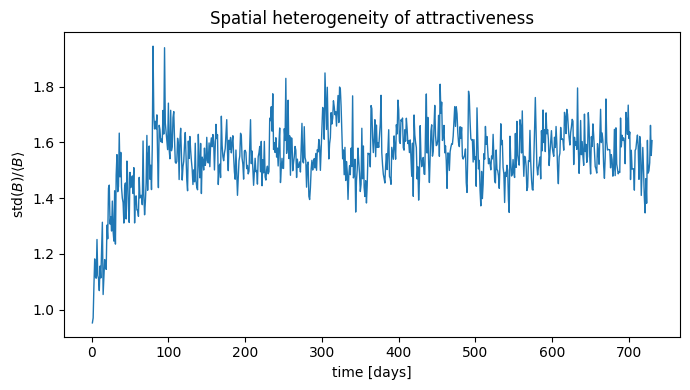

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(diagnostics["day"], diagnostics["hotspot_index_std_over_mean"], lw=1)
plt.xlabel("time [days]")
plt.ylabel(r"$\mathrm{std}(B) / \langle B \rangle$")
plt.title("Spatial heterogeneity of attractiveness")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3d_hotspot_index.png", dpi=200)
plt.show()


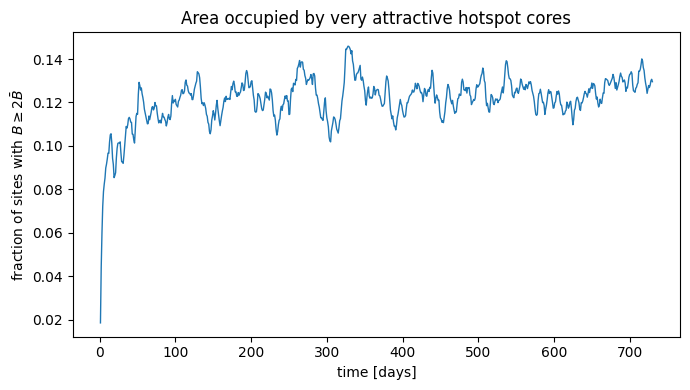

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(diagnostics["day"], diagnostics["fraction_B_above_2Bbar"], lw=1)
plt.xlabel("time [days]")
plt.ylabel(r"fraction of sites with $B \geq 2\bar B$")
plt.title("Area occupied by very attractive hotspot cores")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3d_hotspot_area_fraction.png", dpi=200)
plt.show()



# 6. Interpretation from a complex-systems perspective

This model is a minimal example of **self-organized spatial pattern formation** in a social system.

The feedback loop is:

\[
\text{crime} \rightarrow \text{local attractiveness increase} \rightarrow \text{biased offender motion} \rightarrow \text{more local crime}.
\]

However, the same system also contains two smoothing mechanisms:

1. attractiveness decays with rate \(\omega\),
2. attractiveness diffuses/spreads through neighborhood effects controlled by \(\eta\).

Panel d has:

- small \(\eta=0.03\): attractiveness does not spread too broadly;
- large \(\theta=5.6\): one burglary strongly reinforces local attractiveness;
- small \(\Gamma=0.002\): the criminal population is low, so demographic stochasticity matters.

That is why we do not obtain a smooth homogeneous field or a perfectly stationary hotspot lattice. Instead, we obtain **dynamic hotspots**: coherent spatial structures created by positive feedback, but constantly perturbed by finite-agent stochasticity.



# 7. Notes on reproducibility

Because the paper does not publish the random seed or original code, exact pixel-by-pixel reproduction is impossible. A successful replication should reproduce the regime:

- low criminal population, around the same order of magnitude as the paper;
- strong localized hotspots;
- visible deformation and persistence from early to late snapshots;
- non-stationary realization-dependent morphology.

If your result looks too homogeneous, try another seed. If your result becomes too stationary, check that you are using the panel d parameters, especially `eta=0.03`, `theta=5.6`, and `Gamma=0.002`.
